In [1]:
# MNIST 다운로드
from sklearn.datasets import fetch_openml
import numpy as np

# 1) 내려받기 (처음 1회만 네트워크, 이후 캐시 사용)
mnist = fetch_openml("mnist_784", version=1, as_frame=False)

# 2) X, y 분리
X = mnist.data.astype("float32")     # (70000, 784)
y = mnist.target.astype(np.uint8)    # (70000,), 문자열 → 정수 변환
print(X.shape, y.shape, X.dtype, y.dtype)
# 기대: (70000, 784) (70000,) float32 uint8


(70000, 784) (70000,) float32 uint8


In [2]:
# 기본 통계/형태 확인. 구조 확인
import numpy as np

print("X range:", float(X.min()), "→", float(X.max()))  # 보통 0~255
print("라벨 고유값:", np.unique(y))
print("라벨 분포:", {int(k): int(v) for k, v in zip(*np.unique(y, return_counts=True))})


X range: 0.0 → 255.0
라벨 고유값: [0 1 2 3 4 5 6 7 8 9]
라벨 분포: {0: 6903, 1: 7877, 2: 6990, 3: 7141, 4: 6824, 5: 6313, 6: 6876, 7: 7293, 8: 6825, 9: 6958}


In [3]:
# 한 장 복원 예시. 28×28 복원(reshape) 팁
i = 0
img_28 = X[i].reshape(28, 28)  # (784,) -> (28, 28)
label  = y[i]
print("예시 라벨:", label)


예시 라벨: 5


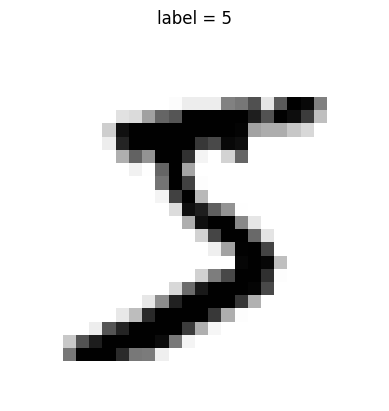

In [4]:
# 단일 이미지 시각화
import matplotlib.pyplot as plt

def plot_digit(image_1d):
    image_2d = image_1d.reshape(28, 28)
    plt.imshow(image_2d, cmap="binary")  # 흑백
    plt.axis("off")

plot_digit(X[0])
plt.title(f"label = {y[0]}")
plt.show()


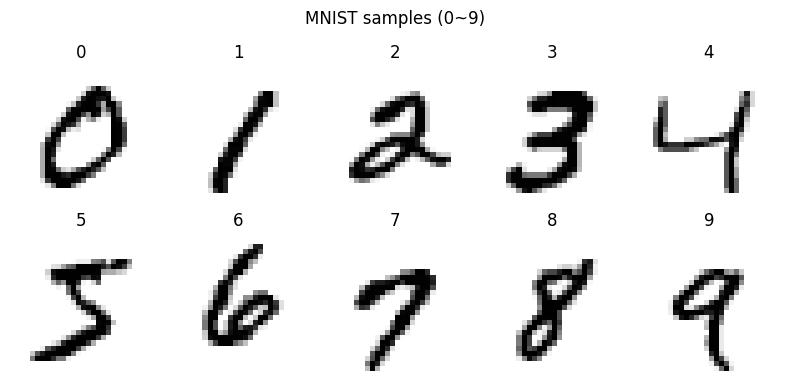

In [6]:
# 여러 장 그리드로 보기(클래스별 예시 10장)
import numpy as np
import matplotlib.pyplot as plt

# 각 숫자(0~9)에서 1장씩 뽑아 2행×5열로 보기
plt.figure(figsize=(8, 4))
picked = []
for digit in range(10):
    idx = np.where(y == digit)[0][0]
    picked.append(idx)

for j, idx in enumerate(picked):
    plt.subplot(2, 5, j + 1)
    plt.imshow(X[idx].reshape(28, 28), cmap="binary")
    plt.title(f"{y[idx]}")
    plt.axis("off")

plt.suptitle("MNIST samples (0~9)")
plt.tight_layout()
plt.show()


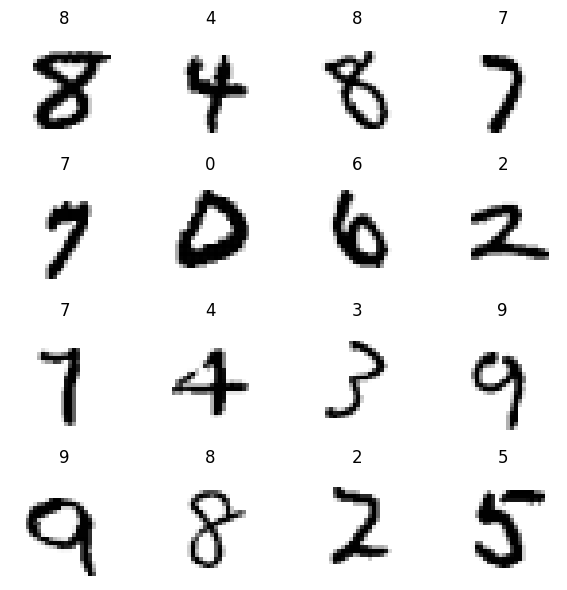

In [7]:
# 무작위 샘플 여러 장 보기
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
idxs = np.random.choice(len(X), size=16, replace=False)

plt.figure(figsize=(6, 6))
for i, idx in enumerate(idxs):
    plt.subplot(4, 4, i + 1)
    plt.imshow(X[idx].reshape(28, 28), cmap="binary")
    plt.title(int(y[idx]))
    plt.axis("off")
plt.tight_layout()
plt.show()


mnist 데이터 불러오기 완료

In [8]:
import numpy as np
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from joblib import dump

# (전제) X, y 준비
X_all = X.astype(np.float32)
y_all = y.astype(int) if y.dtype.kind in "OUS" else y

# 기본 SGD + 반복수 축소 + 관대한 tol → 빨리 끝남 (전처리/튜닝 없음)
sgd = SGDClassifier(random_state=42, max_iter=300, tol=1e-2)

# 3-fold로 시간 단축
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(sgd, X_all, y_all, cv=cv, n_jobs=-1, method="predict")

print("\n=== 기본 SGD (3-fold, fast) ===")
print("Accuracy:", accuracy_score(y_all, y_pred_cv))
print(classification_report(y_all, y_pred_cv, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_all, y_pred_cv))

# 전체 70k로 재학습 & 저장 (동일 설정)
sgd.fit(X_all, y_all)
dump(sgd, "sgd_mnist_baseline_fast.joblib")
print("\n[저장 완료] sgd_mnist_baseline_fast.joblib")




=== 기본 SGD (3-fold, fast) ===
Accuracy: 0.8766
              precision    recall  f1-score   support

           0     0.9550    0.9539    0.9545      6903
           1     0.9543    0.9507    0.9525      7877
           2     0.9080    0.8319    0.8683      6990
           3     0.8431    0.8661    0.8545      7141
           4     0.8563    0.9238    0.8888      6824
           5     0.7463    0.8528    0.7960      6313
           6     0.9385    0.9366    0.9375      6876
           7     0.9184    0.9025    0.9104      7293
           8     0.8594    0.6708    0.7535      6825
           9     0.7910    0.8623    0.8251      6958

    accuracy                         0.8766     70000
   macro avg     0.8770    0.8752    0.8741     70000
weighted avg     0.8793    0.8766    0.8760     70000

Confusion matrix:
 [[6585    0   33   37   30   72   55   10   32   49]
 [   1 7489   44   50   21   41   14   16  156   45]
 [  66  116 5815  312  122   75  114  111  199   60]
 [  24   17  15

최적의 하이퍼파라미터 찾는 과정 --

In [2]:
import numpy as np
from joblib import dump
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# (전제) X, y 메모리에 있음
X_all = X.astype(np.float32)
y_all = y.astype(int) if y.dtype.kind in "OUS" else y

# 교차검증(빨리하려면 3-fold, 더 엄밀하면 5-fold)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


1) RandomizedSearchCV ( 15분 소요 )

In [ ]:
# fast2stage_sgd_bestof.py
# - MNIST용 SGDClassifier 2-Stage 튜닝 (속도↑ + 성능 안정↑)
# - Stage-1: RandomizedSearch(다운샘플, cv=2) → 넓게 훑기
# - Stage-2: GridSearch(전량, cv=3) → 좁혀서 미세조정
# - 희소/밀집 자동 스케일러 선택, early_stopping/average 기본 적용

import numpy as np
from joblib import dump
from scipy.stats import loguniform, uniform

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MaxAbsScaler
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, GridSearchCV

# -----------------------------
# 0) 데이터 & 공통 설정
# -----------------------------
# ⚠️ 여기서 X, y 는 미리 메모리에 있다고 가정 (MNIST 로드된 상태)
X_all = X.astype(np.float32)
y_all = y.astype(int) if hasattr(y, "dtype") and y.dtype.kind in "OUS" else y

# 희소 여부에 따라 스케일러 선택
try:
    from scipy import sparse as _sp
    IS_SPARSE = _sp.issparse(X_all)
except Exception:
    IS_SPARSE = False

scaler = MaxAbsScaler() if IS_SPARSE else StandardScaler(with_mean=False)

cv_fast  = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
cv_final = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 파이프라인(스케일러 + SGD)
base_pipe = Pipeline([
    ("scaler", scaler),
    ("clf", SGDClassifier(
        random_state=42,
        early_stopping=True,      # 내부 검증으로 조기 종료
        validation_fraction=0.1,
        n_iter_no_change=8,
        tol=1e-3,
        average=True,             # 가중치 평균화 → 일반화/수렴 안정
        shuffle=True
    ))
])

# -----------------------------
# 1) 다운샘플링 (≈ 클래스당 1,500 → 총 ~15k)
#    - 클래스별 균등 추출로 편향 방지
# -----------------------------
rng = np.random.RandomState(42)
per_class = 1500   # 속도↑: 1000 / 정확도↑: 2000~3000
idxs = []
for cls in np.unique(y_all):
    cls_idx = np.where(y_all == cls)[0]
    take = min(per_class, len(cls_idx))
    idxs.append(rng.choice(cls_idx, size=take, replace=False))
idxs = np.concatenate(idxs)
X_sub, y_sub = X_all[idxs], y_all[idxs]

# -----------------------------
# 2) Stage-1: 랜덤 서치 (다운샘플, cv=2)
#    - 넓게 "좋은 영역"을 찾는다
# -----------------------------
param_dist = {
    "clf__loss": ["hinge", "log_loss", "modified_huber"],
    "clf__alpha": loguniform(1e-6, 3e-3),
    "clf__penalty": ["l2", "elasticnet"],
    "clf__l1_ratio": uniform(0.0, 1.0),
    "clf__learning_rate": ["optimal", "constant"],
    "clf__eta0": loguniform(3e-4, 3e-2),
    "clf__max_iter": [600],
    "clf__tol": [1e-3],
}
rs = RandomizedSearchCV(
    base_pipe,
    param_distributions=param_dist,
    n_iter=18,
    cv=cv_fast,
    n_jobs=-1,
    scoring="accuracy",
    random_state=42,
    verbose=1
)
rs.fit(X_sub, y_sub)
print("[Stage-1] best acc (sub, cv=2):", rs.best_score_)
print("[Stage-1] best params:", rs.best_params_)

best1 = rs.best_params_

# -----------------------------
# 3) Stage-2: 좁혀진 후보로 정밀 탐색 (전량, cv=3)
#    - Stage-1 최적값 주변만 미세 조정
# -----------------------------
def around_logspace(center, down=0.6, up=1.8, k=7):
    lo = max(center * down, 1e-7)
    hi = center * up
    return np.unique(np.clip(np.geomspace(lo, hi, k), 1e-7, None))

best_alpha = best1.get("clf__alpha", 1e-4)
best_eta0  = best1.get("clf__eta0",  0.001)
best_loss  = best1.get("clf__loss",  "log_loss")
best_pen   = best1.get("clf__penalty", "l2")
best_lr    = best1.get("clf__learning_rate", "optimal")
best_l1r   = best1.get("clf__l1_ratio", 0.15)

param_grid_narrow = {
    "clf__loss": [best_loss],
    "clf__alpha": list(around_logspace(best_alpha, 0.6, 1.8, k=7)),
    "clf__penalty": [best_pen],
    "clf__l1_ratio": [best_l1r] if best_pen == "elasticnet" else [0.15],
    "clf__learning_rate": [best_lr],
    "clf__eta0": (
        list(around_logspace(best_eta0, 0.6, 1.8, k=5))
        if best_lr == "constant" else [0.001]
    ),
    "clf__max_iter": [900],
    "clf__tol": [1e-3],
}

gs = GridSearchCV(
    base_pipe,
    param_grid=param_grid_narrow,
    cv=cv_final,
    n_jobs=-1,
    scoring="accuracy",
    verbose=1,
    return_train_score=True,   # 🔴 이거 중요: train score도 저장하게 함
)
gs.fit(X_all, y_all)

print("[Stage-2] best acc (full, cv=3):", gs.best_score_)
print("[Stage-2] best params:", gs.best_params_)

# -----------------------------
# (추가) Stage-2에서 과적합/과소적합 확인
# -----------------------------
cvres = gs.cv_results_
train_scores = cvres["mean_train_score"]
val_scores = cvres["mean_test_score"]
params = cvres["params"]

print("\n[Stage-2] Train vs Validation Score Summary")
print("==============================================")
for mean_train, mean_val, p in zip(train_scores, val_scores, params):
    diff = mean_train - mean_val
    print(
        f"Train={mean_train:.4f} | Val={mean_val:.4f} | Diff={diff:.4f} | Params={p}"
    )

avg_diff = np.mean(train_scores - val_scores)
print("----------------------------------------------")
print(f"[Stage-2] 평균 Train-Val 차이: {avg_diff:.4f}")
print("----------------------------------------------")

# -----------------------------
# 4) 전량으로 최종 재학습 & 저장
# -----------------------------
best_pipe = gs.best_estimator_
best_pipe.fit(X_all, y_all)
dump(best_pipe, "sgd_best_fast2stage.joblib")
print("[저장] sgd_best_fast2stage.joblib")


Fitting 2 folds for each of 18 candidates, totalling 36 fits
[Stage-1] best acc (sub, cv=2): 0.8994666666666666
[Stage-1] best params: {'clf__alpha': np.float64(2.656695256115112e-06), 'clf__eta0': np.float64(0.002934101104997822), 'clf__l1_ratio': np.float64(0.034388521115218396), 'clf__learning_rate': 'constant', 'clf__loss': 'hinge', 'clf__max_iter': 600, 'clf__penalty': 'elasticnet', 'clf__tol': 0.001}
Fitting 3 folds for each of 35 candidates, totalling 105 fits


2) GridSearchCV

In [8]:
# ====== FAST GRIDSEARCH for SGD (시간 단축 버전) ======
import numpy as np
from joblib import dump
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# --- 데이터 준비 ---
X_all = X.astype(np.float32)
y_all = y.astype(int) if y.dtype.kind in "OUS" else y

# --- 빠른 교차검증 설정 (cv=2로 시간 단축) ---
cv_fast = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

# --- 공통 파이프라인 ---
base = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("clf", SGDClassifier(random_state=42))
])

# === 포인트: 조건부 조합을 '분리'해서 불필요한 fit 제거 ===
# 1) learning_rate='optimal' → eta0 불필요
grid_opt_l2 = {
    "clf__loss": ["hinge", "log_loss"],
    "clf__penalty": ["l2"],
    "clf__alpha": [1e-4, 3e-4, 1e-3],
    "clf__learning_rate": ["optimal"],
    "clf__max_iter": [600],   # 1000 -> 600 (탐색 단계 단축)
    "clf__tol": [1e-3],
}
grid_opt_elastic = {
    "clf__loss": ["hinge", "log_loss"],
    "clf__penalty": ["elasticnet"],
    "clf__l1_ratio": [0.15, 0.5],
    "clf__alpha": [1e-4, 3e-4, 1e-3],
    "clf__learning_rate": ["optimal"],
    "clf__max_iter": [600],
    "clf__tol": [1e-3],
}

# 2) learning_rate='constant' → eta0만 소형 그리드
grid_const_l2 = {
    "clf__loss": ["hinge", "log_loss"],
    "clf__penalty": ["l2"],
    "clf__alpha": [1e-4, 3e-4, 1e-3],
    "clf__learning_rate": ["constant"],
    "clf__eta0": [0.001, 0.01],
    "clf__max_iter": [600],
    "clf__tol": [1e-3],
}

def run_gs(param_grid, name):
    gs = GridSearchCV(
        base, param_grid, cv=cv_fast, n_jobs=-1,
        scoring="accuracy", verbose=0
    )
    gs.fit(X_all, y_all)
    print(f"[{name}] best acc(cv=2): {gs.best_score_:.5f} | params: {gs.best_params_}")
    return gs

# --- 세 개의 '작은' 그리드를 독립 실행 (조건 충족 조합만 평가) ---
gs1 = run_gs(grid_opt_l2,      "OPT-L2")
gs2 = run_gs(grid_opt_elastic, "OPT-ELASTIC")
gs3 = run_gs(grid_const_l2,    "CONST-L2")

# --- 최고 성능 모델 선택 ---
candidates = [gs1, gs2, gs3]
best_gs = max(candidates, key=lambda g: g.best_score_)

print("\n[SELECT] best(of 3) acc(cv=2):", best_gs.best_score_)
print("[SELECT] best params:", best_gs.best_params_)

# --- 최종: 전량으로 '충분히' 재학습(수렴 여유 ↑) & 저장 ---
best_pipe = best_gs.best_estimator_
best_pipe.set_params(clf__max_iter=1000, clf__tol=1e-3)  # 최종 수렴 충분히
best_pipe.fit(X_all, y_all)

dump(best_pipe, "sgd_best_grid_fast.joblib")
print("\n[SAVED] sgd_best_grid_fast.joblib")


[OPT-L2] best acc(cv=2): 0.89541 | params: {'clf__alpha': 0.001, 'clf__learning_rate': 'optimal', 'clf__loss': 'log_loss', 'clf__max_iter': 600, 'clf__penalty': 'l2', 'clf__tol': 0.001}
[OPT-ELASTIC] best acc(cv=2): 0.89619 | params: {'clf__alpha': 0.001, 'clf__l1_ratio': 0.15, 'clf__learning_rate': 'optimal', 'clf__loss': 'log_loss', 'clf__max_iter': 600, 'clf__penalty': 'elasticnet', 'clf__tol': 0.001}
[CONST-L2] best acc(cv=2): 0.91273 | params: {'clf__alpha': 0.001, 'clf__eta0': 0.001, 'clf__learning_rate': 'constant', 'clf__loss': 'log_loss', 'clf__max_iter': 600, 'clf__penalty': 'l2', 'clf__tol': 0.001}

[SELECT] best(of 3) acc(cv=2): 0.9127285714285713
[SELECT] best params: {'clf__alpha': 0.001, 'clf__eta0': 0.001, 'clf__learning_rate': 'constant', 'clf__loss': 'log_loss', 'clf__max_iter': 600, 'clf__penalty': 'l2', 'clf__tol': 0.001}

[SAVED] sgd_best_grid_fast.joblib


3) Greedy(탐욕적) 단계 튜닝

In [23]:
# fast_greedy_sgd.py
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler  # (희소행렬이면 MaxAbsScaler가 더 빠름)
from joblib import dump
import tempfile

# ── 캐시 디렉토리로 변환기 재사용 (CV 반복 시 스케일러 재적용 방지) ──
cache_dir = tempfile.mkdtemp(prefix="skcache_")

pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("clf", SGDClassifier(
        random_state=42,
        # ▶ 속도·성능 균형 키포인트
        early_stopping=True,          # 내부 검증셋으로 조기 종료
        validation_fraction=0.1,
        n_iter_no_change=5,
        tol=1e-3,                     # 수렴 허용오차 (너무 작게 하면 느려짐)
        average=True                  # 파라미터 평균화: 일반화 + 수렴 안정
    ))
], memory=cache_dir)

# 참고: 사용하던 CV 객체를 그대로 씀 (cv 변수가 이미 있음)
# X_all, y_all 도 이미 준비되어 있다고 가정

# ── (1) loss/alpha ────────────────────────────────────────────────────────────
# 불필요한 반복 최소화: max_iter는 여기서만 그리드로 고정하고 이후 단계는 상속
gs1 = GridSearchCV(
    pipe,
    {
        "clf__loss": ["hinge", "log_loss"],
        "clf__alpha": [1e-5, 1e-4, 1e-3],
        "clf__max_iter": [1000],      # 충분히 크고 early_stopping이 알아서 멈춤
    },
    cv=cv, n_jobs=-1, scoring="accuracy", verbose=1, return_train_score=False
)
gs1.fit(X_all, y_all)
print("[Greedy-1]", gs1.best_params_, gs1.best_score_)

# ── (2) learning_rate/eta0 ───────────────────────────────────────────────────
# 중요: 'optimal'일 때 eta0는 무시되므로, 리스트 그리드로 나눠서 '헛연산' 제거
gs2 = GridSearchCV(
    gs1.best_estimator_,
    [
        {"clf__learning_rate": ["optimal"]},              # eta0 없이
        {"clf__learning_rate": ["constant"], "clf__eta0": [0.001, 0.01]},
    ],
    cv=cv, n_jobs=-1, scoring="accuracy", verbose=1, return_train_score=False
)
gs2.fit(X_all, y_all)
print("[Greedy-2]", gs2.best_params_, gs2.best_score_)

# ── (3) penalty/l1_ratio ─────────────────────────────────────────────────────
# 중요: l2에서는 l1_ratio가 무시되므로, 역시 리스트 그리드로 분리
gs3 = GridSearchCV(
    gs2.best_estimator_,
    [
        {"clf__penalty": ["l2"]},
        {"clf__penalty": ["elasticnet"], "clf__l1_ratio": [0.15, 0.5]},
    ],
    cv=cv, n_jobs=-1, scoring="accuracy", verbose=1, return_train_score=False
)
gs3.fit(X_all, y_all)
print("[Greedy-3]", gs3.best_params_, gs3.best_score_)

best_sgd = gs3.best_estimator_.fit(X_all, y_all)  # 전체 데이터로 최종 적합
dump(best_sgd, "sgd_best_greedy.joblib")
print("Saved: sgd_best_greedy.joblib")


Fitting 3 folds for each of 6 candidates, totalling 18 fits
[Greedy-1] {'clf__alpha': 1e-05, 'clf__loss': 'hinge', 'clf__max_iter': 1000} 0.9120571011891899
Fitting 3 folds for each of 3 candidates, totalling 9 fits
[Greedy-2] {'clf__eta0': 0.001, 'clf__learning_rate': 'constant'} 0.9169856897623854
Fitting 3 folds for each of 3 candidates, totalling 9 fits
[Greedy-3] {'clf__penalty': 'l2'} 0.9169856897623854
Saved: sgd_best_greedy.joblib


4. Halving Incremental Search

In [7]:
# -*- coding: utf-8 -*-
"""
SGD 하이퍼파라미터 자동 탐색 (빠르고 효율적) — FIXED
- 포인트:
  * CV 중에는 early_stopping을 끈다(오류 방지)
  * Halving의 min_resources를 충분히 크게 설정
  * 입력 (X, y) 사전 셔플로 클래스 편향 완화
"""

import numpy as np
from joblib import dump
import tempfile
from scipy.stats import loguniform, uniform

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MaxAbsScaler
from sklearn.kernel_approximation import RBFSampler
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import StratifiedKFold

# Halving 계열
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.model_selection import HalvingRandomSearchCV, HalvingGridSearchCV

# ===== 0) 환경/데이터 =====
# X, y 는 이미 메모리에 있다고 가정
X_all = X.astype(np.float32)
y_all = np.asarray(y)

# ★ 사전 셔플: Halving이 작은 n_samples로 시작할 때 클래스 치우침 방지
rng = np.random.RandomState(42)
perm = rng.permutation(X_all.shape[0])
try:
    X_all = X_all[perm]   # scipy.sparse 도 OK (행 인덱싱)
except Exception:
    # 드물게 인덱싱이 어려운 커스텀 객체일 수 있어 방어적 처리
    from sklearn.utils import shuffle as _shuffle
    X_all, y_all = _shuffle(X_all, y_all, random_state=42)
else:
    y_all = y_all[perm]

# 희소 여부 따라 스케일러 선택
try:
    from scipy import sparse as _sp
    IS_SPARSE = _sp.issparse(X_all)
except Exception:
    IS_SPARSE = False

scaler = MaxAbsScaler() if IS_SPARSE else StandardScaler(with_mean=False)

# 교차검증 설정
cv_fast  = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_final = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 파이프라인 캐시(변환 재활용)
cache_dir = tempfile.mkdtemp(prefix="skcache_")

# ===== 1) 플래그: RBF 근사 포함 여부 =====
USE_RBF = True  # False로 바꾸면 "순수 선형 SGD" 탐색

# ===== 2) 파이프라인 구성 =====
# ★ CV 단계에서는 early_stopping=False 로 고정 (내부 검증 split 금지)
sgd_base = SGDClassifier(
    random_state=42,
    early_stopping=False,     # ★ 핵심 변경: CV 중에는 끈다
    validation_fraction=0.1,  # (무시됨)
    n_iter_no_change=8,
    tol=1e-3,
    average=True,
    shuffle=True
)

steps = [("scaler", scaler)]
if USE_RBF:
    steps.append(("rbf", RBFSampler(random_state=42)))
steps.append(("clf", sgd_base))
base_pipe = Pipeline(steps, memory=cache_dir)

# ===== 3) 탐색 공간 정의 =====
def make_param_distributions(use_rbf=True):
    sgd_space = {
        "clf__loss": ["hinge", "modified_huber", "log_loss"],
        "clf__penalty": ["l2", "elasticnet"],
        "clf__l1_ratio": uniform(0.0, 0.3),
        "clf__alpha": loguniform(1e-7, 3e-4),
        "clf__learning_rate": ["optimal", "constant"],
        "clf__eta0": loguniform(1e-4, 3e-2),
        "clf__max_iter": [700],
        "clf__tol": [1e-3],
        # "clf__early_stopping": [False],  # 굳이 공간에 넣지 않고 base에서 고정
    }
    if not use_rbf:
        return sgd_space

    rbf_space = {
        "rbf__gamma": loguniform(1e-4, 3e-1),
        "rbf__n_components": [400, 600, 800, 1000, 1200],
    }
    rbf_space.update(sgd_space)
    return rbf_space

def make_param_grid(center_params, use_rbf=True):
    def around(v, ratio_lo=0.8, ratio_hi=1.25, k=3):
        lo, hi = max(v * ratio_lo, 1e-12), v * ratio_hi
        return list(np.unique(np.geomspace(lo, hi, k))) if v > 0 and np.isfinite(v) else [v]

    grid = {
        "clf__loss": [center_params.get("clf__loss", "log_loss")],
        "clf__penalty": [center_params.get("clf__penalty", "l2")],
        "clf__l1_ratio": [float(center_params.get("clf__l1_ratio", 0.1))] if center_params.get("clf__penalty") == "elasticnet" else [0.1],
        "clf__alpha": around(float(center_params.get("clf__alpha", 1e-5))),
        "clf__learning_rate": [center_params.get("clf__learning_rate", "optimal")],
        "clf__eta0": around(float(center_params.get("clf__eta0", 1e-3))) if center_params.get("clf__learning_rate", "optimal") == "constant" else [1e-3],
        "clf__max_iter": [900],
        "clf__tol": [1e-3],
        # "clf__early_stopping": [False],  # grid에서도 고정
    }
    if use_rbf:
        grid.update({
            "rbf__gamma": around(float(center_params.get("rbf__gamma", 1e-3))),
            "rbf__n_components": sorted(set([
                max(300, int(center_params.get("rbf__n_components", 800)) - 100),
                int(center_params.get("rbf__n_components", 800)),
                int(center_params.get("rbf__n_components", 800)) + 100
            ])),
        })
    return grid

# ===== 4) Stage-A: HalvingRandomSearchCV (빠른 1차 탐색) =====
param_dist = make_param_distributions(USE_RBF)

# ★ 클래스 수에 안전한 최소 자원 설정
n_classes = int(np.unique(y_all).shape[0])
n_splits  = 3
# 각 fold의 test에도 모든 클래스가 들어오도록 여유 있게(경험적) 설정
safe_min_resources = max(512, 10 * n_classes * n_splits)

hrs = HalvingRandomSearchCV(
    base_pipe,
    param_distributions=param_dist,
    n_candidates="exhaust",
    factor=3,
    resource="n_samples",
    min_resources=safe_min_resources,   # ★ 추가
    max_resources="auto",
    aggressive_elimination=True,
    cv=cv_fast,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
    random_state=42,
    # error_score=0.0,  # 필요시 활성화: 일부 실패 무시하고 진행
)
hrs.fit(X_all, y_all)
print("\n[Stage-A] best acc:", hrs.best_score_)
print("[Stage-A] best params:", hrs.best_params_)

# ===== 5) Stage-B: HalvingGridSearchCV (근방 미세조정) =====
param_grid = make_param_grid(hrs.best_params_, USE_RBF)
hgs = HalvingGridSearchCV(
    base_pipe,
    param_grid=param_grid,
    factor=3,
    resource="n_samples",
    min_resources=safe_min_resources,   # ★ 동일 적용
    max_resources="auto",
    aggressive_elimination=True,
    cv=cv_final,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1,
    # error_score=0.0,
)
hgs.fit(X_all, y_all)
print("\n[Stage-B] best acc:", hgs.best_score_)
print("[Stage-B] best params:", hgs.best_params_)

# ===== 6) 최종 재학습 & 저장 =====
# ★ 최종 전체 데이터 재학습 때만 early_stopping을 켠 버전으로 교체(선택)
best_params = hgs.best_params_

# 최종용 파이프라인 구성
final_steps = [("scaler", scaler)]
if USE_RBF:
    final_steps.append(("rbf", RBFSampler(random_state=42)))
final_sgd = SGDClassifier(
    random_state=42,
    early_stopping=True,          # ★ 최종에서만 ON (데이터 충분)
    validation_fraction=0.1,
    n_iter_no_change=8,
    tol=1e-3,
    average=True,
    shuffle=True,
    max_iter=1100                 # ★ 조금 늘려 학습 여유
)
final_steps.append(("clf", final_sgd))
final_pipe = Pipeline(final_steps, memory=cache_dir)

# best params 반영 (rbf/sgd 공통)
final_pipe.set_params(**best_params)
final_pipe.fit(X_all, y_all)
dump(final_pipe, "sgd_best_halving.joblib")
print("\n[SAVED] sgd_best_halving.joblib")


n_iterations: 5
n_required_iterations: 5
n_possible_iterations: 5
min_resources_: 512
max_resources_: 70000
aggressive_elimination: True
factor: 3
----------
iter: 0
n_candidates: 136
n_resources: 512
Fitting 3 folds for each of 136 candidates, totalling 408 fits
----------
iter: 1
n_candidates: 46
n_resources: 1536
Fitting 3 folds for each of 46 candidates, totalling 138 fits
----------
iter: 2
n_candidates: 16
n_resources: 4608
Fitting 3 folds for each of 16 candidates, totalling 48 fits
----------
iter: 3
n_candidates: 6
n_resources: 13824
Fitting 3 folds for each of 6 candidates, totalling 18 fits
----------
iter: 4
n_candidates: 2
n_resources: 41472
Fitting 3 folds for each of 2 candidates, totalling 6 fits

[Stage-A] best acc: 0.9260429707699996
[Stage-A] best params: {'clf__alpha': np.float64(1.6823821974707638e-06), 'clf__eta0': np.float64(0.0005688269085079675), 'clf__l1_ratio': np.float64(0.049396755942882516), 'clf__learning_rate': 'optimal', 'clf__loss': 'hinge', 'clf__max_

In [9]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from joblib import dump

# MNIST 데이터 준비 (이미 X, y 메모리에 있다고 가정)
X_all = X.astype(np.float32)
y_all = y.astype(int) if y.dtype.kind in "OUS" else y

# 1) Logistic Regression 기본 모델 정의
# - solver="lbfgs": 멀티클래스 자동 지원
# - max_iter 늘려줌 (기본값 100 → 수렴 가능하도록 300)
log_clf = LogisticRegression(max_iter=300, n_jobs=-1, random_state=42)

# 2) 3-Fold 교차검증 → 빠르게 대략적인 성능 파악
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(log_clf, X_all, y_all, cv=cv, n_jobs=-1, method="predict")

# 3) 성능 출력
print("\n=== Logistic Regression (3-fold CV, 기본 설정) ===")
print("Accuracy:", accuracy_score(y_all, y_pred_cv))
print(classification_report(y_all, y_pred_cv, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_all, y_pred_cv))

# 4) 전체 데이터로 다시 학습 후 저장
log_clf.fit(X_all, y_all)
dump(log_clf, "logreg_mnist_baseline.joblib")
print("\n[저장 완료] logreg_mnist_baseline.joblib")



=== Logistic Regression (3-fold CV, 기본 설정) ===
Accuracy: 0.9150142857142857
              precision    recall  f1-score   support

           0     0.9516    0.9629    0.9572      6903
           1     0.9549    0.9705    0.9627      7877
           2     0.9108    0.8883    0.8994      6990
           3     0.8905    0.8905    0.8905      7141
           4     0.9239    0.9228    0.9233      6824
           5     0.8814    0.8582    0.8697      6313
           6     0.9408    0.9498    0.9453      6876
           7     0.9308    0.9235    0.9271      7293
           8     0.8721    0.8700    0.8711      6825
           9     0.8833    0.9014    0.8922      6958

    accuracy                         0.9150     70000
   macro avg     0.9140    0.9138    0.9138     70000
weighted avg     0.9149    0.9150    0.9149     70000

Confusion matrix:
 [[6647    1   34   24   17   51   52   15   49   13]
 [   1 7645   38   31    6   30   10   19   84   13]
 [  50   87 6209  134   77   36   92   

1) RandomizedSearchCV

In [6]:
# logreg_speed90_full.py
# - 속도 최적화된 2-Stage RandomizedSearchCV 로지스틱 회귀 (MNIST 90%↑ 목표)
# - 밀집행렬: lbfgs + L2만 / 희소행렬: saga + L2만
# - Stage-2 n_iter=7 (공간 크기 경고 제거)
# - 다운샘플(클래스 균등)로 Stage-1 가속

import numpy as np
from joblib import dump
from scipy.stats import loguniform
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# ===== (선택) 경고를 조용히 하고 싶다면 주석 해제 =====
# import warnings
# from sklearn.exceptions import ConvergenceWarning
# warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.linear_model._logistic")
# warnings.filterwarnings("ignore", category=ConvergenceWarning)

# ======================================================================
# 0) 데이터 준비: (전제) X, y 가 메모리에 존재해야 함
#    - 희소/밀집 모두 안전하게 처리
# ======================================================================
X_all = X.astype(np.float32)
y_all = y.astype(int) if hasattr(y, "dtype") and y.dtype.kind in "OUS" else y

# 희소 여부 판단
try:
    from scipy import sparse as _sp
    IS_SPARSE = _sp.issparse(X_all)
except Exception:
    IS_SPARSE = False

# CV 설정: 빠른 2-fold(탐색) + 3-fold(검증)
cv_fast  = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
cv_final = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 파이프라인 (스케일러: with_mean=False → 희소 안전)
base_pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("clf", LogisticRegression(random_state=42))  # multi_class는 기본값(미지정)으로 경고 회피
])

# ======================================================================
# 1) 다운샘플링 (클래스 균등 추출) — 속도/정확도 밸런스
#    - MNIST면 per_class=1200~2000에서 90%↑ 충분
# ======================================================================
rng = np.random.RandomState(42)
per_class = 1200  # 더 빠르게: 1000 / 더 정확히: 1500~2000
idxs = []
classes = np.unique(y_all)
for c in classes:
    ci = np.where(y_all == c)[0]
    take = min(per_class, len(ci))
    idxs.append(rng.choice(ci, size=take, replace=False))
idxs = np.concatenate(idxs)
X_sub, y_sub = X_all[idxs], y_all[idxs]

# ======================================================================
# 2) Stage-1: 빠른 RandomizedSearch (다운샘플, cv=2)
#    - 밀집:  lbfgs + L2 (가장 빠름/안정)
#    - 희소:  saga  + L2 (희소 호환)
# ======================================================================
if not IS_SPARSE:
    # 밀집 → lbfgs
    space_stage1 = {
        "clf__solver": ["lbfgs"],
        "clf__penalty": ["l2"],
        "clf__C": loguniform(1e-3, 1e2),
        "clf__tol": [1e-3],
        "clf__max_iter": [250],  # 짧게
        "clf__fit_intercept": [True]
    }
else:
    # 희소 → saga (l2만)
    space_stage1 = {
        "clf__solver": ["saga"],
        "clf__penalty": ["l2"],
        "clf__C": loguniform(1e-3, 1e2),
        "clf__tol": [1e-3],
        "clf__max_iter": [400],  # saga는 조금 더
        "clf__fit_intercept": [True]
    }

rs1 = RandomizedSearchCV(
    estimator=base_pipe,
    param_distributions=space_stage1,
    n_iter=12,                     # 속도↑ (8~16 권장)
    cv=cv_fast,
    n_jobs=-1,
    scoring="accuracy",
    random_state=42,
    verbose=1
)
rs1.fit(X_sub, y_sub)
print("[Stage-1] acc(sub/cv=2):", rs1.best_score_)
print("[Stage-1] params:", rs1.best_params_)

best = rs1.best_params_
best_C      = best["clf__C"]
best_tol    = best["clf__tol"]
best_solver = best["clf__solver"]

# ======================================================================
# 3) Stage-2: 좁은 범위 RandomizedSearch (전량, cv=3, n_iter=7)
#    - Stage-1의 C 주변만 로그스케일로 재탐색
#    - n_iter=7 : '공간이 n_iter보다 작다' 경고 제거
# ======================================================================
def around_logspace(center, down=0.6, up=1.8, k=7):
    lo = max(center * down, 1e-6)
    hi = center * up
    return np.unique(np.geomspace(lo, hi, k))

if best_solver == "lbfgs":
    space_stage2 = {
        "clf__solver": ["lbfgs"],
        "clf__penalty": ["l2"],
        "clf__C": list(around_logspace(best_C, 0.6, 1.8, k=7)),
        "clf__tol": [best_tol],
        "clf__max_iter": [400],  # 살짝만 증가(수렴 여유)
        "clf__fit_intercept": [True]
    }
else:
    space_stage2 = {
        "clf__solver": ["saga"],
        "clf__penalty": ["l2"],
        "clf__C": list(around_logspace(best_C, 0.6, 1.8, k=7)),
        "clf__tol": [best_tol],
        "clf__max_iter": [700],  # saga는 더 여유
        "clf__fit_intercept": [True]
    }

rs2 = RandomizedSearchCV(
    estimator=base_pipe,
    param_distributions=space_stage2,
    n_iter=7,                 # ← 경고 없이 딱 맞춤
    cv=cv_final,
    n_jobs=-1,
    scoring="accuracy",
    random_state=1337,
    verbose=1
)
rs2.fit(X_all, y_all)
print("[Stage-2] acc(full/cv=3):", rs2.best_score_)
print("[Stage-2] params:", rs2.best_params_)

# ======================================================================
# 4) 최종 재학습 & 저장 — 수렴 여유만 크게 설정
#    - lbfgs: max_iter=600
#    - saga : max_iter=1000
# ======================================================================
final_params = {k.replace("clf__", ""): v for k, v in rs2.best_params_.items() if k.startswith("clf__")}
if final_params["solver"] == "lbfgs":
    final_params["max_iter"] = 600
else:
    final_params["max_iter"] = 1000

final_pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("clf", LogisticRegression(**final_params, random_state=42))
])
final_pipe.fit(X_all, y_all)

dump(final_pipe, "logreg_speed90.joblib")
print("[저장] logreg_speed90.joblib")

Fitting 2 folds for each of 12 candidates, totalling 24 fits
[Stage-1] acc(sub/cv=2): 0.9055833333333334
[Stage-1] params: {'clf__C': np.float64(0.0060252157362038605), 'clf__fit_intercept': True, 'clf__max_iter': 250, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs', 'clf__tol': 0.001}
Fitting 3 folds for each of 7 candidates, totalling 21 fits
[Stage-2] acc(full/cv=3): 0.9232142669077029
[Stage-2] params: {'clf__tol': 0.001, 'clf__solver': 'lbfgs', 'clf__penalty': 'l2', 'clf__max_iter': 400, 'clf__fit_intercept': True, 'clf__C': np.float64(0.009030772413509006)}
[저장] logreg_speed90.joblib


2) GridSearchCV

무의미해서 진행하지 않

3) Greedy(탐욕적) 단계 튜닝

In [8]:
# fast_greedy_logreg.py
# - 단계별(Greedy) 튜닝으로 LogisticRegression 최적화
# - 속도 과도하게 느려지지 않도록 탐색폭을 현실적으로 제한
# - 밀집: lbfgs+L2 우선 / 희소: saga+L2도 후보
# - 최종 적합 시 random_state 중복 전달 에러 해결(pop 처리)

import numpy as np
from joblib import dump
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MaxAbsScaler
from sklearn.linear_model import LogisticRegression
import tempfile

# (전제) X, y 가 메모리에 존재
X_all = X.astype(np.float32)
y_all = y.astype(int) if hasattr(y, "dtype") and y.dtype.kind in "OUS" else y

# ── CV 준비: 이미 cv가 있으면 사용, 없으면 생성 ────────────────────────────
try:
    cv  # noqa: F821
except NameError:
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# ── 희소 여부 판단 ───────────────────────────────────────────────────────────
try:
    from scipy import sparse as _sp
    IS_SPARSE = _sp.issparse(X_all)
except Exception:
    IS_SPARSE = False

# ── 캐시 디렉토리(파이프라인 변환기 재사용) ────────────────────────────────
cache_dir = tempfile.mkdtemp(prefix="skcache_")

# ── 스케일러 선택 ───────────────────────────────────────────────────────────
#   - 희소: MaxAbsScaler(빠르고 안전)
#   - 밀집: StandardScaler(with_mean=False)로 일관성 유지(희소 호환 설정)
scaler = MaxAbsScaler() if IS_SPARSE else StandardScaler(with_mean=False)

# ── 파이프라인 골격 ─────────────────────────────────────────────────────────
pipe = Pipeline([
    ("scaler", scaler),
    ("clf", LogisticRegression(
        random_state=42  # multi_class는 기본값(=자동)으로 두어 경고 회피
    ))
], memory=cache_dir)

# ── C 그리드(속도/성능 밸런스) ─────────────────────────────────────────────
C_GRID_COARSE = np.geomspace(1e-3, 1e-1, 4)   # [0.001, 0.0032, 0.01, 0.0316]
C_GRID_FINE   = np.geomspace(0.003, 0.03, 5)  # lbfgs에서 주로 잘 나오는 구간

# ── (1) solver/penalty 가족 선택 ────────────────────────────────────────────
space_step1 = []

# 밀집 기본 후보: lbfgs + L2 (빠르고 안정)
space_step1.append({
    "clf__solver": ["lbfgs"],
    "clf__penalty": ["l2"],
    "clf__C": C_GRID_COARSE,
    "clf__tol": [1e-3],
    "clf__max_iter": [300],   # 수렴 빠르게
    "clf__fit_intercept": [True],
})

# 희소면 saga + L2도 간단 비교
if IS_SPARSE:
    space_step1.append({
        "clf__solver": ["saga"],
        "clf__penalty": ["l2"],
        "clf__C": C_GRID_COARSE,
        "clf__tol": [1e-3],
        "clf__max_iter": [500],  # saga는 여유 조금 더
        "clf__fit_intercept": [True],
    })

gs1 = GridSearchCV(
    pipe,
    space_step1,
    cv=cv, n_jobs=-1, scoring="accuracy", verbose=1, return_train_score=False
)
gs1.fit(X_all, y_all)
print("[Greedy-1]", gs1.best_params_, gs1.best_score_)

# ── (2) C 미세조정 ──────────────────────────────────────────────────────────
best_est     = gs1.best_estimator_
best_solver  = gs1.best_params_["clf__solver"]
best_penalty = gs1.best_params_["clf__penalty"]

space_step2 = [{
    "clf__solver": [best_solver],
    "clf__penalty": [best_penalty],
    "clf__C": C_GRID_FINE,
    "clf__tol": [1e-3],
    "clf__max_iter": [500 if best_solver == "saga" else 400],
    "clf__fit_intercept": [True],
}]

gs2 = GridSearchCV(
    best_est,
    space_step2,
    cv=cv, n_jobs=-1, scoring="accuracy", verbose=1, return_train_score=False
)
gs2.fit(X_all, y_all)
print("[Greedy-2]", gs2.best_params_, gs2.best_score_)

# ── (3) (선택) saga일 때만 elasticnet 소폭 확인 ────────────────────────────
use_step3 = (best_solver == "saga")
if use_step3:
    space_step3 = [
        # 유지: L2
        {
            "clf__solver": ["saga"],
            "clf__penalty": ["l2"],
            "clf__C": [gs2.best_params_["clf__C"]],
            "clf__tol": [1e-3],
            "clf__max_iter": [700],
            "clf__fit_intercept": [True],
        },
        # 가벼운 elasticnet 체크(작은 후보만)
        {
            "clf__solver": ["saga"],
            "clf__penalty": ["elasticnet"],
            "clf__l1_ratio": [0.15, 0.5],
            "clf__C": [gs2.best_params_["clf__C"]],
            "clf__tol": [1e-3],
            "clf__max_iter": [700],
            "clf__fit_intercept": [True],
        },
    ]
    gs3 = GridSearchCV(
        gs2.best_estimator_,
        space_step3,
        cv=cv, n_jobs=-1, scoring="accuracy", verbose=1, return_train_score=False
    )
    gs3.fit(X_all, y_all)
    print("[Greedy-3]", gs3.best_params_, gs3.best_score_)
    final_est = gs3.best_estimator_
else:
    final_est = gs2.best_estimator_

# ── (4) 전체 데이터로 최종 적합 & 저장 ─────────────────────────────────────
#    - random_state 중복 전달 방지(pop) + max_iter 여유 확대
final_params = final_est.get_params()
clf_params = {k.replace("clf__",""): v for k, v in final_params.items() if k.startswith("clf__")}
clf_params.pop("random_state", None)  # ← TypeError 방지(중복 제거)
clf_params["max_iter"] = 600 if clf_params.get("solver","lbfgs") == "lbfgs" else 1000

final_pipe = Pipeline([
    ("scaler", scaler),
    ("clf", LogisticRegression(random_state=42, **clf_params)),
], memory=cache_dir)

best_logreg = final_pipe.fit(X_all, y_all)
dump(best_logreg, "logreg_best_greedy.joblib")
print("Saved: logreg_best_greedy.joblib")


Fitting 3 folds for each of 4 candidates, totalling 12 fits
[Greedy-1] {'clf__C': np.float64(0.021544346900318832), 'clf__fit_intercept': True, 'clf__max_iter': 300, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs', 'clf__tol': 0.001} 0.9227142671115777
Fitting 3 folds for each of 5 candidates, totalling 15 fits
[Greedy-2] {'clf__C': np.float64(0.009486832980505141), 'clf__fit_intercept': True, 'clf__max_iter': 400, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs', 'clf__tol': 0.001} 0.92329997996898
Saved: logreg_best_greedy.joblib


In [3]:
# logreg_halving_full.py
# ------------------------------------------------------------
# Logistic Regression + (옵션) RBF 특성 근사
# HalvingRandomSearchCV (ElasticNet/L2 각각) → 베스트 선택 → HalvingGrid 미세조정
# 경고 해결:
#  - penalty가 'l2'일 때 l1_ratio 전달 안 함 (경고 제거)
#  - multi_class 파라미터 사용 안 함 (1.5 deprecated → 제거)
# 전제: 메모리에 X, y 존재 (numpy/scipy sparse OK)
# ------------------------------------------------------------

import numpy as np
import tempfile
from joblib import dump

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MaxAbsScaler
from sklearn.kernel_approximation import RBFSampler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.model_selection import HalvingRandomSearchCV, HalvingGridSearchCV

from scipy.stats import loguniform, uniform

# =========================
# 0) 데이터 준비/부분샘플
# =========================
X_all = X  # NOTE: 사용자가 미리 정의했다고 가정
y_all = y

# 형 변환 & 셔플(초기 라운드 클래스 치우침 방지)
X_all = X_all.astype(np.float32, copy=False)
y_all = np.asarray(y_all)

rng = np.random.RandomState(42)
idx = rng.permutation(X_all.shape[0])
try:
    X_all = X_all[idx]   # sparse도 행 인덱싱 가능
except Exception:
    from sklearn.utils import shuffle as _shuffle
    X_all, y_all = _shuffle(X_all, y_all, random_state=42)
else:
    y_all = y_all[idx]

# (선택) 빠른 실행용 부분샘플
MAX_N = 40000            # 더 빨리 하려면 30k/20k로 내리세요
if X_all.shape[0] > MAX_N:
    X_all, y_all = X_all[:MAX_N], y_all[:MAX_N]

# 희소/밀집 스케일러 자동 선택
try:
    from scipy import sparse as _sp
    IS_SPARSE = _sp.issparse(X_all)
except Exception:
    IS_SPARSE = False
scaler = MaxAbsScaler() if IS_SPARSE else StandardScaler(with_mean=False)

# =========================
# 1) 옵션: RBF 근사 사용 여부
# =========================
USE_RBF = True  # False면 선형(LogReg)만 → 훨씬 빠름

# =========================
# 2) 파이프라인 베이스
# =========================
base_steps = [("scaler", scaler)]
if USE_RBF:
    base_steps.append(("rbf", RBFSampler(random_state=42)))
base_steps.append(("clf", LogisticRegression(
    solver="saga",        # elasticnet/대규모 데이터 적합
    n_jobs=-1,
    max_iter=500,         # CV 중에는 400~600이면 충분
    tol=1e-3,
    random_state=42
)))
base_pipe = Pipeline(base_steps, memory=tempfile.mkdtemp(prefix="skcache_"))

# =========================
# 3) 탐색 공간 정의
# =========================
def dist_elasticnet(use_rbf=True):
    space = {
        "clf__penalty": ["elasticnet"],
        "clf__l1_ratio": uniform(0.0, 0.3),
        "clf__C": loguniform(1e-2, 3e+1),   # 0.01 ~ 30
        "clf__max_iter": [500],
        "clf__tol": [1e-3],
    }
    if use_rbf:
        space.update({
            "rbf__gamma": loguniform(1e-4, 3e-2),
            "rbf__n_components": [400, 700, 1000],
        })
    return space

def dist_l2(use_rbf=True):
    space = {
        "clf__penalty": ["l2"],
        # l1_ratio 미포함 → 경고 제거
        "clf__C": loguniform(1e-2, 3e+1),
        "clf__max_iter": [500],
        "clf__tol": [1e-3],
    }
    if use_rbf:
        space.update({
            "rbf__gamma": loguniform(1e-4, 3e-2),
            "rbf__n_components": [400, 700, 1000],
        })
    return space

def make_param_grid(center, use_rbf=True):
    def around(v, lo=0.7, hi=1.4, k=3):
        if (not np.isfinite(v)) or (v <= 0): return [v]
        vals = np.geomspace(max(v*lo, 1e-12), v*hi, k)
        return list(np.unique(vals))

    grid = {
        "clf__penalty": [center.get("clf__penalty", "elasticnet")],
        "clf__C": around(float(center.get("clf__C", 1.0))),
        "clf__max_iter": [600],
        "clf__tol": [1e-3],
    }
    # penalty가 elasticnet이면 l1_ratio 포함
    if center.get("clf__penalty", "elasticnet") == "elasticnet":
        grid["clf__l1_ratio"] = [float(center.get("clf__l1_ratio", 0.05))]

    if use_rbf:
        if "rbf__gamma" in center:
            grid["rbf__gamma"] = around(float(center.get("rbf__gamma", 5e-4)))
        if "rbf__n_components" in center:
            nc = int(center.get("rbf__n_components", 700))
            grid["rbf__n_components"] = sorted(set([max(300, nc-200), nc, nc+200]))
    return grid

# =========================
# 4) Halving 설정 (안전/속도)
# =========================
cv_fast  = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_final = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

n_classes = int(np.unique(y_all).shape[0])
safe_min_resources = max(1536, 6 * n_classes * cv_fast.get_n_splits())  # 분할 오류 방지

def run_halving_random(name, param_distributions):
    hrs = HalvingRandomSearchCV(
        estimator=base_pipe,
        param_distributions=param_distributions,
        n_candidates="exhaust",      # 더 빠르게: 정수(예: 80/60)로 제한
        factor=3,
        resource="n_samples",
        min_resources=safe_min_resources,
        max_resources="auto",
        aggressive_elimination=True,
        scoring="accuracy",
        cv=cv_fast,
        n_jobs=-1,
        verbose=1,
        random_state=42,
        error_score=0.0,
    )
    print(f"\n[Stage-A/{name}] searching...")
    hrs.fit(X_all, y_all)
    print(f"[Stage-A/{name}] best acc:", hrs.best_score_)
    print(f"[Stage-A/{name}] best params:", hrs.best_params_)
    return hrs

# =========================
# 5) Stage-A: ElasticNet / L2 각각 탐색
# =========================
hrs_en = run_halving_random("ElasticNet", dist_elasticnet(USE_RBF))
hrs_l2 = run_halving_random("L2",         dist_l2(USE_RBF))

# 두 결과 중 더 좋은 쪽 선택
if hrs_en.best_score_ >= hrs_l2.best_score_:
    winner_name   = "ElasticNet"
    winner_params = hrs_en.best_params_
    winner_score  = hrs_en.best_score_
else:
    winner_name   = "L2"
    winner_params = hrs_l2.best_params_
    winner_score  = hrs_l2.best_score_

print(f"\n[Stage-A] winner = {winner_name} | acc={winner_score:.6f}")

# =========================
# 6) Stage-B: 근방 미세조정
# =========================
param_grid = make_param_grid(winner_params, USE_RBF)
hgs = HalvingGridSearchCV(
    estimator=base_pipe,
    param_grid=param_grid,
    factor=3,
    resource="n_samples",
    min_resources=safe_min_resources,
    max_resources="auto",
    aggressive_elimination=True,
    scoring="accuracy",
    cv=cv_final,
    n_jobs=-1,
    verbose=1,
    error_score=0.0,
)
print("\n[Stage-B] grid refining...")
hgs.fit(X_all, y_all)
print("[Stage-B] best acc:", hgs.best_score_)
print("[Stage-B] best params:", hgs.best_params_)

# =========================
# 7) 최종 재학습 & 저장 (경고 제거 버전)
# =========================
best_params = hgs.best_params_

# 최종 파이프라인 구성
final_steps = [("scaler", scaler)]
if USE_RBF:
    final_steps.append(("rbf", RBFSampler(random_state=42)))

# penalty에 따라 l1_ratio 조건부 전달 → 경고 제거
pen = best_params.get("clf__penalty", "elasticnet")
ratio = best_params.get("clf__l1_ratio", None) if pen == "elasticnet" else None

final_clf = LogisticRegression(
    solver="saga",
    n_jobs=-1,
    penalty=pen,
    l1_ratio=ratio,                     # elasticnet일 때만 유효
    C=best_params.get("clf__C", 1.0),
    max_iter=800,                       # 최종 학습 여유
    tol=1e-4,                           # 살짝 더 엄격
    random_state=42,
)

final_steps.append(("clf", final_clf))
final_pipe = Pipeline(final_steps, memory=None)

# rbf/clf 파라미터 일괄 반영
final_pipe.set_params(**best_params)
final_pipe.fit(X_all, y_all)
dump(final_pipe, "logreg_halving.joblib")
print("\n[SAVED] logreg_halving.joblib")


[Stage-A/ElasticNet] searching...
n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 1536
max_resources_: 40000
aggressive_elimination: True
factor: 3
----------
iter: 0
n_candidates: 26
n_resources: 1536
Fitting 3 folds for each of 26 candidates, totalling 78 fits
----------
iter: 1
n_candidates: 9
n_resources: 4608
Fitting 3 folds for each of 9 candidates, totalling 27 fits
----------
iter: 2
n_candidates: 3
n_resources: 13824
Fitting 3 folds for each of 3 candidates, totalling 9 fits
[Stage-A/ElasticNet] best acc: 0.9102158852470877
[Stage-A/ElasticNet] best params: {'clf__C': np.float64(16.676512684158038), 'clf__l1_ratio': np.float64(0.21818159875692625), 'clf__max_iter': 500, 'clf__penalty': 'elasticnet', 'clf__tol': 0.001, 'rbf__gamma': np.float64(0.0006439928994620849), 'rbf__n_components': 700}

[Stage-A/L2] searching...
n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 1536
max_resources_: 40000
aggressive_elimin